# Notebook 03: Unsupervised Clustering

Loads the pre-computed 14-feature matrices from nb02 and runs unsupervised clustering:

1. **K-Means** — sweep k=2–6, select by silhouette score
2. **Leiden** — graph-based clustering, sweep resolution

Both methods use the same 14 spatial features (Moran's I + local gradient for 7 TLS signatures).
KC/LC manual annotations (ETLS/MTLS/GC) are used post-hoc only — never seen during clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load feature matrices ─────────────────────────────────────────────────
rcc  = np.load('../data/processed/feature_matrix_rcc.npz',  allow_pickle=True)
kclc = np.load('../data/processed/feature_matrix_kclc.npz', allow_pickle=True)

X_rcc           = rcc['X'].astype(np.float32)
y_rcc           = rcc['y']
train_mask_rcc  = rcc['train_mask']
feat_names      = rcc['feature_names'].tolist()
sample_ids_rcc  = rcc['sample_ids']

X_kclc          = kclc['X'].astype(np.float32)
y_kclc          = kclc['y']
eval_mask_kclc  = kclc['eval_mask']
label_fine      = kclc['label_fine']
label_eval      = kclc['label_eval']
sample_ids_kclc = kclc['sample_ids']

n_rcc, n_kclc = len(X_rcc), len(X_kclc)

# Combined matrix for clustering (per-dataset z-score already applied)
X_all    = np.vstack([X_rcc, X_kclc])
dataset  = np.array(['rcc'] * n_rcc + ['kclc'] * n_kclc)

print(f'RCC:      {X_rcc.shape}  — {train_mask_rcc.sum()} annotated')
print(f'KC/LC:    {X_kclc.shape} — {eval_mask_kclc.sum()} eval-eligible')
print(f'Combined: {X_all.shape}')
print(f'\nFeatures ({len(feat_names)}):\n  ' + '\n  '.join(feat_names))

RCC:      (73280, 14)  — 61063 annotated
KC/LC:    (19404, 14) — 8890 eval-eligible
Combined: (92684, 14)

Features (14):
  score_b_cell_core_local_moran
  score_cxcl13_anchor_local_moran
  score_plasma_output_local_moran
  score_t_cell_zone_local_moran
  score_tfh_local_moran
  score_tls_chemokines_local_moran
  score_tregs_local_moran
  score_b_cell_core_local_grad
  score_cxcl13_anchor_local_grad
  score_plasma_output_local_grad
  score_t_cell_zone_local_grad
  score_tfh_local_grad
  score_tls_chemokines_local_grad
  score_tregs_local_grad


## 1. K-Means Clustering

Sweep k = 2–6, select by silhouette score. Clustering runs on all spots (RCC + KC/LC combined).
KC/LC labels are not visible to the clustering algorithm.

  k=2: silhouette=0.5917  cluster sizes={0: 89460, 1: 3224}
  k=3: silhouette=0.0929  cluster sizes={0: 52008, 1: 38306, 2: 2370}
  k=4: silhouette=0.0797  cluster sizes={0: 4501, 1: 38681, 2: 1920, 3: 47582}
  k=5: silhouette=0.0723  cluster sizes={0: 3995, 1: 39495, 2: 1348, 3: 43771, 4: 4075}
  k=6: silhouette=0.0675  cluster sizes={0: 3538, 1: 8142, 2: 3534, 3: 36990, 4: 39194, 5: 1286}

Best k: 2  (silhouette=0.5917)


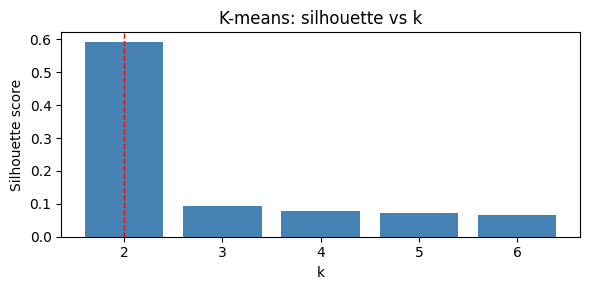

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores, km_models = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_all)
    sil  = silhouette_score(X_all, labs, sample_size=10000, random_state=42)
    sil_scores[k] = sil
    km_models[k]  = (km, labs)
    print(f'  k={k}: silhouette={sil:.4f}  cluster sizes={dict(zip(*np.unique(labs, return_counts=True)))}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k: {best_k}  (silhouette={sil_scores[best_k]:.4f})')
km_best, km_labels_all = km_models[best_k]

# Bar chart of silhouette scores
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(list(sil_scores.keys()), list(sil_scores.values()), color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('k'); ax.set_ylabel('Silhouette score')
ax.set_title('K-means: silhouette vs k')
plt.tight_layout()
plt.savefig('../checkpoints/kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Leiden Clustering

Graph-based clustering on the same combined feature matrix.
Sweep resolution = 0.2, 0.5, 1.0.

In [3]:
import anndata as ad
import scanpy as sc

adata_cl = ad.AnnData(X=X_all.copy())
sc.pp.neighbors(adata_cl, n_neighbors=15, use_rep='X', random_state=42)
print('KNN graph built')

leiden_sil = {}
for res in [0.2, 0.5, 1.0]:
    key = f'leiden_{res}'
    sc.tl.leiden(adata_cl, resolution=res, key_added=key, random_state=42)
    labs = adata_cl.obs[key].astype(int).values
    n_cl = len(np.unique(labs))
    sil  = silhouette_score(X_all, labs, sample_size=10000, random_state=42)
    leiden_sil[res] = (n_cl, sil)
    print(f'  res={res}: {n_cl} clusters, silhouette={sil:.4f}')

best_res = max(leiden_sil, key=lambda r: leiden_sil[r][1])
print(f'\nBest resolution: {best_res}  ({leiden_sil[best_res][0]} clusters, '
      f'silhouette={leiden_sil[best_res][1]:.4f})')
leiden_labels_all = adata_cl.obs[f'leiden_{best_res}'].astype(int).values

KNN graph built
  res=0.2: 3 clusters, silhouette=0.1967
  res=0.5: 8 clusters, silhouette=-0.0305
  res=1.0: 17 clusters, silhouette=-0.0723

Best resolution: 0.2  (3 clusters, silhouette=0.1967)


## 6. UMAP Visualization

UMAP computed: (92684, 2)


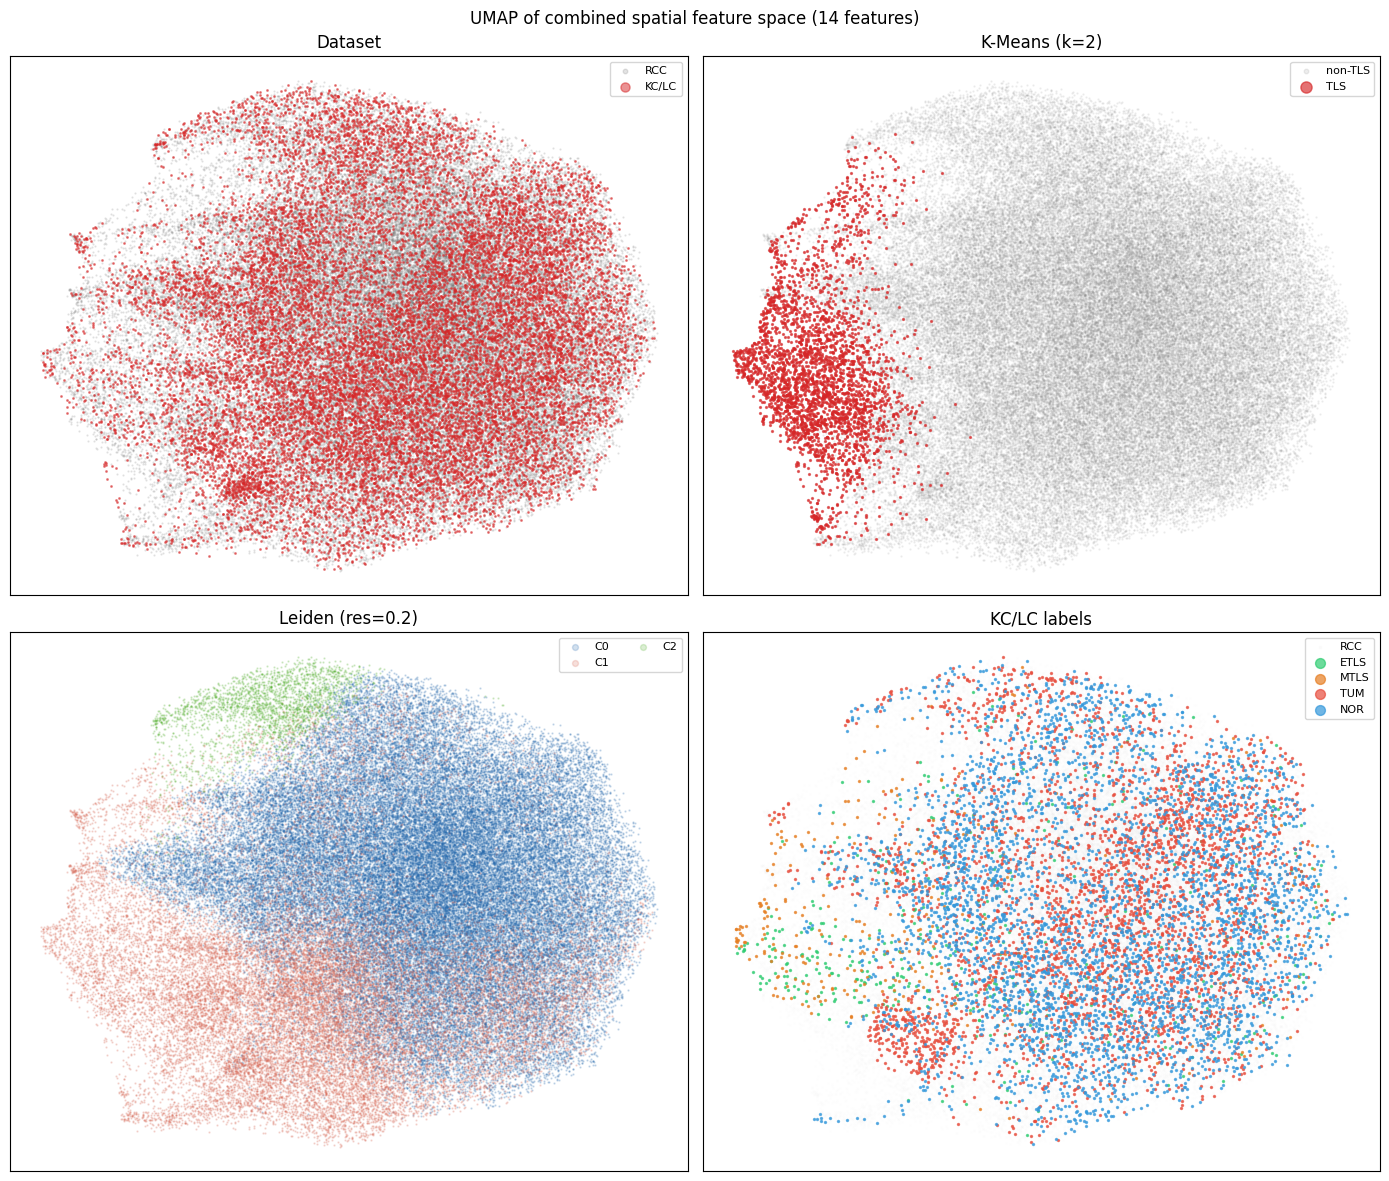

Saved → checkpoints/umap_clustering.png


In [8]:
sc.tl.umap(adata_cl, random_state=42)
umap = adata_cl.obsm['X_umap']
print(f'UMAP computed: {umap.shape}')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ── Panel 1: Dataset ──────────────────────────────────────────────────────
m_rcc  = dataset == 'rcc'
m_kclc = dataset == 'kclc'
axes[0,0].scatter(umap[m_rcc, 0],  umap[m_rcc, 1],  c='#666666', s=0.3, alpha=0.18,
                  label='RCC', rasterized=True)
axes[0,0].scatter(umap[m_kclc, 0], umap[m_kclc, 1], c='#d62728', s=1.2, alpha=0.50,
                  label='KC/LC', rasterized=True)
axes[0,0].set_title('Dataset'); axes[0,0].legend(markerscale=6, fontsize=8)

# ── Panel 2: K-Means ──────────────────────────────────────────────────────
rcc_km = km_labels_all[:n_rcc]
tls_cl = max(range(best_k),
             key=lambda c: y_rcc[(rcc_km == c) & train_mask_rcc].mean()
             if ((rcc_km == c) & train_mask_rcc).sum() > 0 else 0)
# Draw non-TLS first (background), TLS last (foreground)
for cl in sorted(range(best_k), key=lambda c: c == tls_cl):
    m = km_labels_all == cl
    if cl == tls_cl:
        axes[0,1].scatter(umap[m,0], umap[m,1], c='#d62728', s=1.8, alpha=0.65,
                          label='TLS', rasterized=True)
    else:
        axes[0,1].scatter(umap[m,0], umap[m,1], c='#888888', s=0.3, alpha=0.15,
                          label='non-TLS', rasterized=True)
axes[0,1].set_title(f'K-Means (k={best_k})'); axes[0,1].legend(markerscale=6, fontsize=8)

# ── Panel 3: Leiden ───────────────────────────────────────────────────────
leiden_palette = ['#2166ac', '#d6604d', '#4dac26', '#984ea3',
                  '#ff7f00', '#a65628', '#f781bf', '#999999']
n_leiden = len(np.unique(leiden_labels_all))
for cl in range(n_leiden):
    m = leiden_labels_all == cl
    axes[1,0].scatter(umap[m,0], umap[m,1], c=leiden_palette[cl % len(leiden_palette)],
                      s=0.5, alpha=0.20, label=f'C{cl}', rasterized=True)
axes[1,0].set_title(f'Leiden (res={best_res})')
axes[1,0].legend(markerscale=6, fontsize=8, ncol=2)

# ── Panel 4: KC/LC labels (RCC as faint background — intentional) ─────────
axes[1,1].scatter(umap[m_rcc,0], umap[m_rcc,1], c='#cccccc', s=0.1,
                  alpha=0.05, rasterized=True, label='RCC')
for lbl, color in label_colors.items():
    m_lbl = np.zeros(len(X_all), dtype=bool)
    m_lbl[n_rcc:] = label_eval == lbl
    if m_lbl.sum() == 0:
        continue
    axes[1,1].scatter(umap[m_lbl,0], umap[m_lbl,1], c=color, s=2.0,
                      alpha=0.70, label=lbl, rasterized=True)
axes[1,1].set_title('KC/LC labels')
axes[1,1].legend(markerscale=5, fontsize=8)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('UMAP of combined spatial feature space (14 features)', fontsize=12)
plt.tight_layout()
plt.savefig('../checkpoints/umap_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/umap_clustering.png')


## Next Steps

**nb04** — post-hoc clinical validation:
- Map cluster TLS scores to RCC IgG staining (pct_igg_tumor in obs)
- Survival analysis (PFS/OS) stratified by cluster-based TLS score
- Cross-cancer summary figure